# 📊 Proyecto: Análisis de Campañas de Marketing Bancario
Este proyecto tiene como objetivo realizar un EDA para entender el comportamiento de los clientes y mejorar la segmentación. 

---

## Configuración del Entorno y Librerías
Comenzamos importando las herramientas necesarias para el análisis y configuramos la visualización.

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt # Librería básica de gráficos en Python, muy versátil para crear todo tipo de visualizaciones
import seaborn as sns # Librería especializada en gráficos estadísticos, construida sobre Matplotlib pero con un estilo más moderno y funciones más fáciles de usar para análisis de datos

pd.set_option('display.max_info_columns', 100) # Permite mostrar hasta 100 columnas en .info()
pd.set_option('display.max_columns', None)     # Muestra todas las columnas en .head()


In [54]:
# Cargamos el archivo de marketing (el CSV) con la ruta correcta
df_marketing = pd.read_csv('../datos/bank-additional.csv')

# Cargamos las 3 hojas del Excel con la misma lógica
hoja1 = pd.read_excel('../datos/customer-details.xlsx', sheet_name=0) # hoja 1
hoja2 = pd.read_excel('../datos/customer-details.xlsx', sheet_name=1) # hoja 2
hoja3 = pd.read_excel('../datos/customer-details.xlsx', sheet_name=2) # hoja 3

# Unimos las 3 hojas en una sola tabla de clientes
df_clientes = pd.concat([hoja1, hoja2, hoja3])

# Unimos las dos tablas usando el ID como pegamento
df_final = pd.merge(df_marketing, df_clientes, left_on='id_', right_on='ID')
# Unimos df_marketing con df_clientes usando la columna 'id_' de df_marketing y la columna 'ID' de df_clientes como clave de unión

df_clean = df_final.copy() # Hacemos una copia para limpiar sin perder el original

print(f"Tu tabla de trabajo (df_clean) tiene {df_clean.shape[1]} columnas.") # Imprime el número de columnas del DataFrame final para confirmar que se han unido correctamente
print("✅ ¡Archivos cargados con éxito! El mapa funcionó a la perfección.")
df_clean.head()

Tu tabla de trabajo (df_clean) tiene 31 columnas.
✅ ¡Archivos cargados con éxito! El mapa funcionó a la perfección.


,Unnamed: 0_x,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,latitude,longitude,id_,Unnamed: 0_y,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,ID
0,0,NaN,housemaid,MARRIED,basic.4y,0.0,0.0,0.0,telephone,261,1,999,0,NONEXISTENT,1.1,"93,994","-36,4","4,857",5191,no,2-agosto-2019,41.495,-71.233,089b39d8-e4d0-461b-87d4-814d71e0e079,0,161770,1,0,2012-04-04,29,089b39d8-e4d0-461b-87d4-814d71e0e079
1,1,57.0,services,MARRIED,high.school,NaN,0.0,0.0,telephone,149,1,999,0,NONEXISTENT,1.1,"93,994","-36,4",NaN,5191,no,14-septiembre-2016,34.601,-83.923,e9d37224-cb6f-4942-98d7-46672963d097,1,85477,1,1,2012-12-30,7,e9d37224-cb6f-4942-98d7-46672963d097
2,2,37.0,services,MARRIED,high.school,0.0,1.0,0.0,telephone,226,1,999,0,NONEXISTENT,1.1,"93,994","-36,4","4,857",5191,no,15-febrero-2019,34.939,-94.847,3f9f49b5-e410-4948-bf6e-f9244f04918b,2,147233,1,1,2012-02-02,5,3f9f49b5-e410-4948-bf6e-f9244f04918b
3,3,40.0,admin.,MARRIED,basic.6y,0.0,0.0,0.0,telephone,151,1,999,0,NONEXISTENT,1.1,"93,994","-36,4",NaN,5191,no,29-noviembre-2015,49.041,-70.308,9991fafb-4447-451a-8be2-b0df6098d13e,3,121393,1,2,2012-12-21,29,9991fafb-4447-451a-8be2-b0df6098d13e
4,4,56.0,services,MARRIED,high.school,0.0,0.0,1.0,telephone,307,1,999,0,NONEXISTENT,1.1,"93,994","-36,4",NaN,5191,no,29-enero-2017,38.033,-104.463,eca60b76-70b6-4077-80ba-bc52e8ebb0eb,4,63164,1,2,2012-06-20,20,eca60b76-70b6-4077-80ba-bc52e8ebb0eb


---

### En este paso, evaluamos la estructura y el contenido de la tabla ya unificada. El objetivo es identificar los valores nulos, errores de formato en las columnas y datos innecesarios antes de proceder con la limpieza profunda y el análisis de datos. 

In [55]:
print("Dimensiones (Filas, Columnas)") # Imprime el número de filas y columnas del DataFrame para tener una idea de su tamaño 
df_clean.shape

print("\nInformación de Tipos y Nulos") # Muestra el tipo de datos de cada columna y la cantidad de valores no nulos, lo que ayuda a identificar columnas con datos faltantes o tipos incorrectos
df_clean.info()

print("\nConteo exacto de valores nulos") # Cuenta el número de valores nulos en cada columna, lo que es crucial para saber qué columnas necesitan limpieza o imputación de datos
print(df_clean.isnull().sum()) # Muestra el número de valores nulos por columna, lo que es esencial para identificar qué columnas necesitan limpieza o imputación de datos

Dimensiones (Filas, Columnas)

Información de Tipos y Nulos
<class 'pandas.DataFrame'>
RangeIndex: 43000 entries, 0 to 42999
Data columns (total 31 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Unnamed: 0_x       43000 non-null  int64         
 1   age                37880 non-null  float64       
 2   job                42655 non-null  str           
 3   marital            42915 non-null  str           
 4   education          41193 non-null  str           
 5   default            34019 non-null  float64       
 6   housing            41974 non-null  float64       
 7   loan               41974 non-null  float64       
 8   contact            43000 non-null  str           
 9   duration           43000 non-null  int64         
 10  campaign           43000 non-null  int64         
 11  pdays              43000 non-null  int64         
 12  previous           43000 non-null  int64         
 13  poutcome    

### 🧼 Tras analizar el resumen, se detectan valores nulos en columnas clave y errores de formato en variables económicas, además de columnas innecesarias. Procedemos a la curación de los datos.

In [56]:
# LIMPIEZA (Quitamos las columnas basura que vimos en la información anterior)
df_clean.drop(columns=['Unnamed: 0_x', 'Unnamed: 0_y' , 'ID'], errors='ignore', inplace=True) # Borramos columnas basura de una vez, con errors='ignore' para evitar errores si no existen

# TRATAMIENTO DE NULOS (IMPUTACIÓN)
# Rellenamos la edad con la mediana y el trabajo con la moda
df_clean['age'] = df_clean['age'].fillna(df_clean['age'].median())
df_clean['job'] = df_clean['job'].fillna(df_clean['job'].mode()[0])

# CORRECCIÓN DE FORMATOS ECONÓMICOS (De Texto a Número)
cols_economicas = ['cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
for col in cols_economicas:
    df_clean[col] = pd.to_numeric(df_clean[col].astype(str).str.replace(',', '.'), errors='coerce') 
# Convertimos a string, reemplazamos comas por puntos, y luego convertimos a numérico. Si hay errores, se convierten a NaN (nulos).

# COMPROBACIÓN DE LA CIRUGÍA
# Verificamos si ahora sí son 'float64' (números decimales)
print("Verificación de Tipos de Datos")
print(df_clean[cols_economicas].dtypes)

# Y comprobamos si esa conversión generó nuevos nulos
print("\nNuevos nulos generados por la conversión")
print(df_clean[cols_economicas].isnull().sum())

Verificación de Tipos de Datos
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
dtype: object

Nuevos nulos generados por la conversión
cons.price.idx     471
cons.conf.idx        0
euribor3m         9256
nr.employed          0
dtype: int64


---

### Aquí observamos que tenemos los nuevos nulos generados por la conversión, usaremos la mediana para rellenar esos nuevos nulos, a continuación;

In [57]:
# Usamos la mediana porque son datos numéricos continuos
df_clean['euribor3m'] = df_clean['euribor3m'].fillna(df_clean['euribor3m'].median()) # Rellenamos los nulos de 'euribor3m' con la mediana de esa columna
df_clean['cons.price.idx'] = df_clean['cons.price.idx'].fillna(df_clean['cons.price.idx'].median()) # Rellenamos los nulos de 'cons.price.idx' con la mediana de esa columna

# Verificamos que ahora sí el Gran Total de nulos sea 0
gran_total = df_clean.isnull().sum().sum()
print(f"LIMPIEZA COMPLETADA")
print(f"El Gran Total de nulos en toda la tabla ahora es: {gran_total}")

LIMPIEZA COMPLETADA
El Gran Total de nulos en toda la tabla ahora es: 13173


---

### Siguen apareciendo nulos y el total es de ***13.173***, le pediremos a Python que nos haga una lista exacta de dónde están escondidos esos valores nulos.

In [58]:
# Buscamos exactamente qué columnas nos faltan por limpiar
nulos_restantes = df_clean.isnull().sum() # Contamos los nulos por columna y lo guardamos en una variable

print("Columnas que AÚN tienen nulos:")
# Filtramos para que solo muestre las que tienen más de 0 nulos
print(nulos_restantes[nulos_restantes > 0])

Columnas que AÚN tienen nulos:
marital        85
education    1807
default      8981
housing      1026
loan         1026
date          248
dtype: int64


---

 Ahora que hemos encontrado los datos nulos faltantes en esta lista, observamos que las variables de texto `marital` y `education` tienen en total 1.892 valores nulos. Rellenaremos estas categorías de texto con la MODA. Si la mayoría de los clientes están casados o tienen educación secundaria, asumiremos eso para estos huecos. 

 Las variables financieras (Sí/No) `default` , `housing` , `loan`, observamos que tienen muchos nulos. Como solo hay dos opciones, usaremos también la MODA para asignarlos al grupo mayoritario y no perder esas filas de datos que son valiosas. 

 Las fechas `date` 
 El problema: Faltan 248 fechas de contacto, por lo que inventar una fecha (con media o moda) es peligroso porque puede alterar el análisis temporal. Por lo que, aplicaremos la eliminación total ya que representan apenas el 0.5% de los 43,000 datos.

---

In [59]:
df_clean['marital'] = df_clean['marital'].fillna(df_clean['marital'].mode()[0]) # Rellenamos la variable 'marital' con la moda, es decir, el valor más frecuente en esa columna
df_clean['education'] = df_clean['education'].fillna(df_clean['education'].mode()[0]) # Rellenamos la variable 'education' igualmente con la moda, el valor más común en esa columna

# Rellenamos las variables de Sí/No (0.0/1.0) con la MODA
cols_financieras = ['default', 'housing', 'loan'] 
# Creamos una lista con las columnas que queremos rellenar con la moda, para luego iterar sobre ellas y aplicar el mismo método de imputación a todas
for col in cols_financieras: 
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0]) 

# Borramos las poquitas filas
# subset=['date'] significa "borra la fila ENTERA solo si está vacía en la columna 'date'"
df_clean = df_clean.dropna(subset=['date'])

# LA PRUEBA FINAL
gran_total = df_clean.isnull().sum().sum() # Contamos el gran total de nulos en toda la tabla después de la limpieza para confirmar que ya no quedan
print("¡LIMPIEZA 100% COMPLETADA!")
print(f"El Gran Total de nulos en toda la tabla ahora es: {gran_total}")
print(f"Filas finales listas para analizar: {df_clean.shape[0]}")

¡LIMPIEZA 100% COMPLETADA!
El Gran Total de nulos en toda la tabla ahora es: 0
Filas finales listas para analizar: 42752


In [60]:
# VERIFICACIÓN DE DUPLICADOS
# Contamos cuántas filas son réplicas exactas de otras filas (duplicados) para saber si necesitamos eliminar algunos antes del análisis.
num_duplicados = df_clean.duplicated().sum()
print(f"Se encontraron {num_duplicados} filas duplicadas.")

# ELIMINACIÓN
# Borramos los duplicados conservando solo la primera aparición en caso de que haya filas idénticas 
df_clean = df_clean.drop_duplicates()
print(f"Duplicados eliminados. Filas finales reales para el EDA: {df_clean.shape[0]}")

Se encontraron 0 filas duplicadas.
Duplicados eliminados. Filas finales reales para el EDA: 42752


--- 

### 📊 Una vez curados los datos, procedemos a realizar un análisis descriptivo para comprender las características generales de nuestros clientes, incluyendo promedios, máximos y mínimos de las variables numéricas.

In [61]:
#Resumen estadístico global de las variables numéricas
df_clean.describe(include='all').round(2) # Redondeamos a 2 decimales para mejor legibilidad 

,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,latitude,longitude,id_,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth
count,42752.00,42752,42752,42752,42752.00,42752.00,42752.00,42752,42752.00,42752.00,42752.00,42752.00,42752,42752.00,42752.00,42752.00,42752.00,42752.00,42752,42752,42752.00,42752.00,42752,42752.00,42752.00,42752.00,42752,42752.00
unique,NaN,11,3,7,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,2,1825,NaN,NaN,42752,NaN,NaN,NaN,NaN,NaN
top,NaN,admin.,MARRIED,university.degree,NaN,NaN,NaN,cellular,NaN,NaN,NaN,NaN,NONEXISTENT,NaN,NaN,NaN,NaN,NaN,no,28-febrero-2018,NaN,NaN,089b39d8-e4d0-461b-87d4-814d71e0e079,NaN,NaN,NaN,NaN,NaN
freq,NaN,11146,25925,14436,NaN,NaN,NaN,27232,NaN,NaN,NaN,NaN,36883,NaN,NaN,NaN,NaN,NaN,37941,95,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN
mean,39.75,NaN,NaN,NaN,0.00,0.55,0.15,NaN,257.77,2.57,962.37,0.17,NaN,0.08,93.58,-40.51,3.88,5166.87,NaN,NaN,36.86,-95.94,NaN,93225.59,1.01,1.00,2013-05-12 02:36:15.224551,16.59
min,17.00,NaN,NaN,NaN,0.00,0.00,0.00,NaN,0.00,1.00,0.00,0.00,NaN,-3.40,92.20,-50.80,0.63,4963.60,NaN,NaN,24.40,-125.00,NaN,5841.00,0.00,0.00,2012-01-01 00:00:00,1.00
25%,33.00,NaN,NaN,NaN,0.00,0.00,0.00,NaN,102.00,1.00,999.00,0.00,NaN,-1.80,93.08,-42.70,1.48,5099.10,NaN,NaN,30.62,-110.49,NaN,49587.50,0.00,0.00,2012-07-16 00:00:00,9.00
50%,38.00,NaN,NaN,NaN,0.00,1.00,0.00,NaN,179.00,2.00,999.00,0.00,NaN,1.10,93.75,-41.80,4.86,5191.00,NaN,NaN,36.76,-95.90,NaN,93016.00,1.00,1.00,2013-03-02 00:00:00,17.00
75%,46.00,NaN,NaN,NaN,0.00,1.00,0.00,NaN,319.00,3.00,999.00,0.00,NaN,1.40,93.99,-36.40,4.96,5228.10,NaN,NaN,43.11,-81.44,NaN,136732.00,2.00,2.00,2014-03-29 00:00:00,25.00
max,98.00,NaN,NaN,NaN,1.00,1.00,1.00,NaN,4918.00,56.00,999.00,7.00,NaN,1.40,94.77,-26.90,5.04,5228.10,NaN,NaN,49.38,-66.94,NaN,180802.00,2.00,2.00,2014-12-31 00:00:00,32.00


---

### 📊 Análisis Univariado

Distribución de Edades (Histograma)

A continuación, visualizamos la columna `age` mediante un histograma para entender qué rango de edad predomina en nuestra cartera de clientes. Aplicamos una curva de densidad para identificar visualmente la concentración principal. 

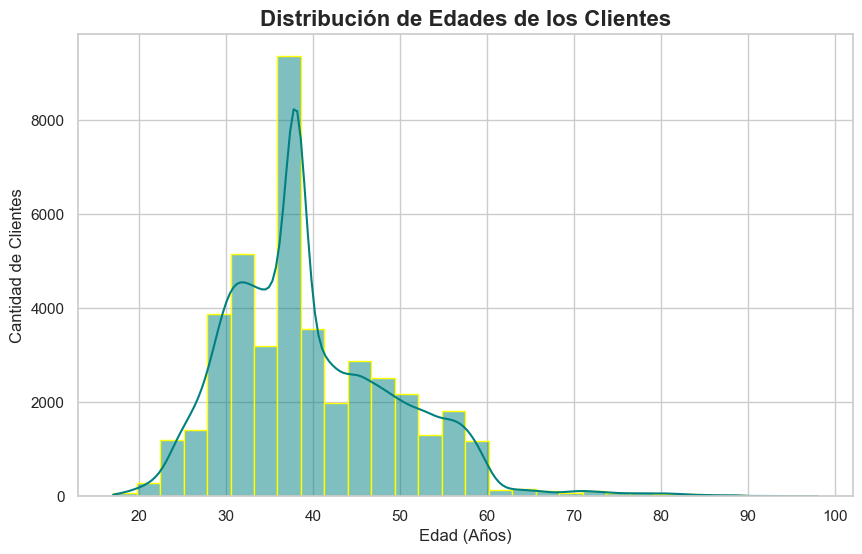

In [62]:
# Configuramos el lienzo (tamaño y estilo)
plt.figure(figsize=(10, 6)) # Define el tamaño del cuadro donde se dibujará el gráfico, 10 de ancho y 6 de alto
sns.set_theme(style="whitegrid") # Aplica un estilo de fondo con cuadrícula para mejorar la legibilidad del gráfico 

# Creamos el histograma de la columna 'age'
sns.histplot(data=df_clean, x='age', bins=30, kde=True, color='teal', edgecolor='yellow') # Histograma con línea de densidad (kde=True) y color personalizado

# Añadimos los títulos en español 
plt.title('Distribución de Edades de los Clientes', fontsize=16, fontweight='bold') # Título del gráfico con tamaño de letra 16 y negrita
plt.xlabel('Edad (Años)', fontsize=12) # Etiqueta del eje X con tamaño de letra 12
plt.ylabel('Cantidad de Clientes', fontsize=12) # Etiqueta del eje Y con tamaño de letra 12

# Mostramos el gráfico
plt.show()

---
### 📝 Interpretación: 

Observamos un pico de concentración de clientes en el rango de 30 a 40 años, lo que representa el núcleo principal de la base de datos. En la distribución observamos que la curva muestra un sesgo hacia la derecha, deducimos que el banco cuenta con una presencia decreciente pero constante de clientes hasta los 60 años. 

Se observa una baja representación de clientes menores de 25 años y mayores de 70 años. Esto sugiere que el producto o la campaña actual está captando principalmente a personas en su etapa de mayor actividad laboral y financiera.

---

### 📊 Detección de Outliers (Boxplots)
Tras analizar las distribuciones, utilizamos diagramas de caja para identificar visualmente los "outliers" en las variables de `age` (edad) e `Income` (ingresos). Esto nos permite detectar si existen perfiles de clientes con características extremas que puedan influir en el promedio general.

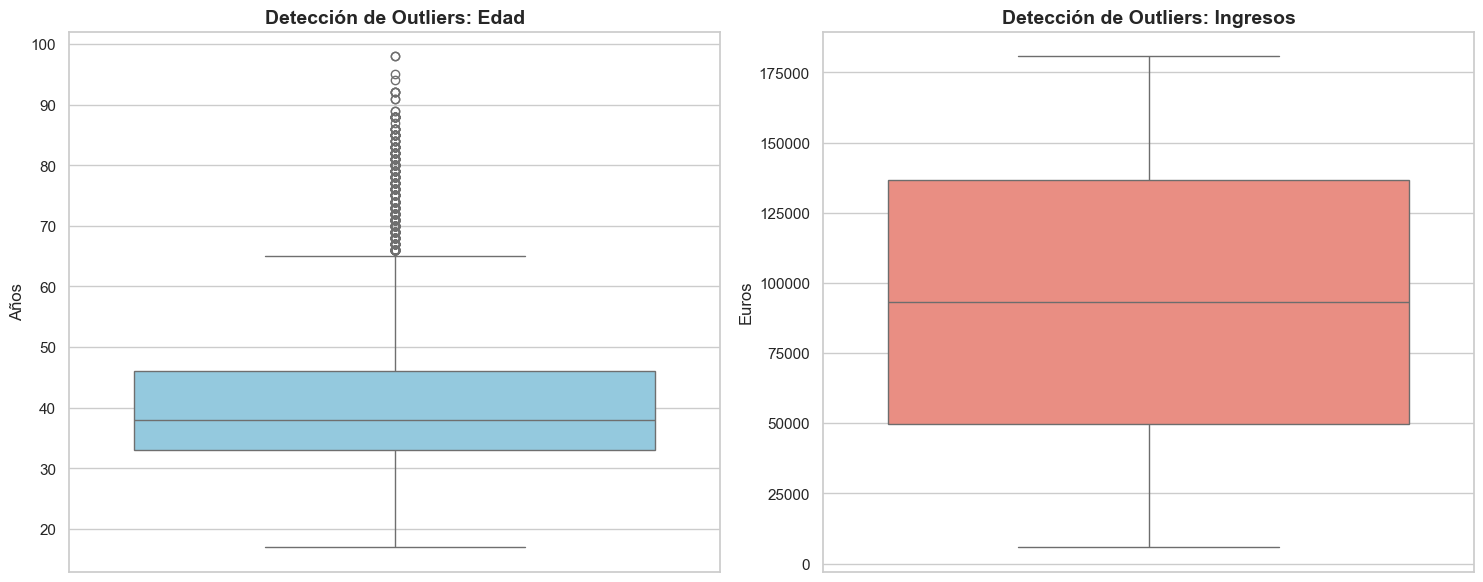

In [63]:
# Configuramos el lienzo para mostrar dos gráficos lado a lado (1 fila, 2 columnas) y aplicamos un estilo de fondo con cuadrícula para mejorar la legibilidad 
fig, ax = plt.subplots(1, 2, figsize=(15, 6)) 
sns.set_theme(style="whitegrid")

# Gráfico 1: Boxplot de Edad
sns.boxplot(data=df_clean, y='age', color='skyblue', ax=ax[0]) # Boxplot de la columna 'age' con color personalizado y asignado al primer gráfico (ax[0]) 
ax[0].set_title('Detección de Outliers: Edad', fontsize=14, fontweight='bold') # Título del gráfico con tamaño de letra 14 y negrita 
ax[0].set_ylabel('Años') # Etiqueta del eje Y con texto "Años"

# Gráfico 2: Boxplot de Ingresos
sns.boxplot(data=df_clean, y='Income', color='salmon', ax=ax[1]) # Boxplot de la columna 'Income' con color personalizado y asignado al segundo gráfico (ax[1]) 
ax[1].set_title('Detección de Outliers: Ingresos', fontsize=14, fontweight='bold') # Título del gráfico con tamaño de letra 14 y negrita
ax[1].set_ylabel('Euros') # Etiqueta del eje Y con texto "Euros"

# Ajuste fino para que no se amontonen
plt.tight_layout() # Ajusta automáticamente el espacio entre los gráficos para que no se solapen ni queden demasiado separados
plt.show()

---

### 📝 Interpretación 
* **Edad (`age`):** Observamos una gran cantidad de valores atípicos por encima de los 65 años (puntos individuales). Esto indica que, aunque el cliente promedio ronda los 40 años, el banco mantiene un segmento minoritario pero significativo de clientes en la tercera edad.
* **Ingresos (`Income`):** Sorprendentemente, **no se detectan valores atípicos**. Toda la distribución está contenida dentro de los límites esperados (desde aprox. 5,000€ hasta 180,000€). Esto significa que la cartera no cuenta con perfiles financieros extremadamente desproporcionados que puedan sesgar la media general.

---

### 📊 Perfil Demográfico (Gráficos de Barras)
A continuación, analizamos la composición demográfica de nuestra cartera de clientes (Estado Civil y Nivel Educativo) mediante gráficos de barras de frecuencias. Esto nos ayudará a entender el perfil predominante.

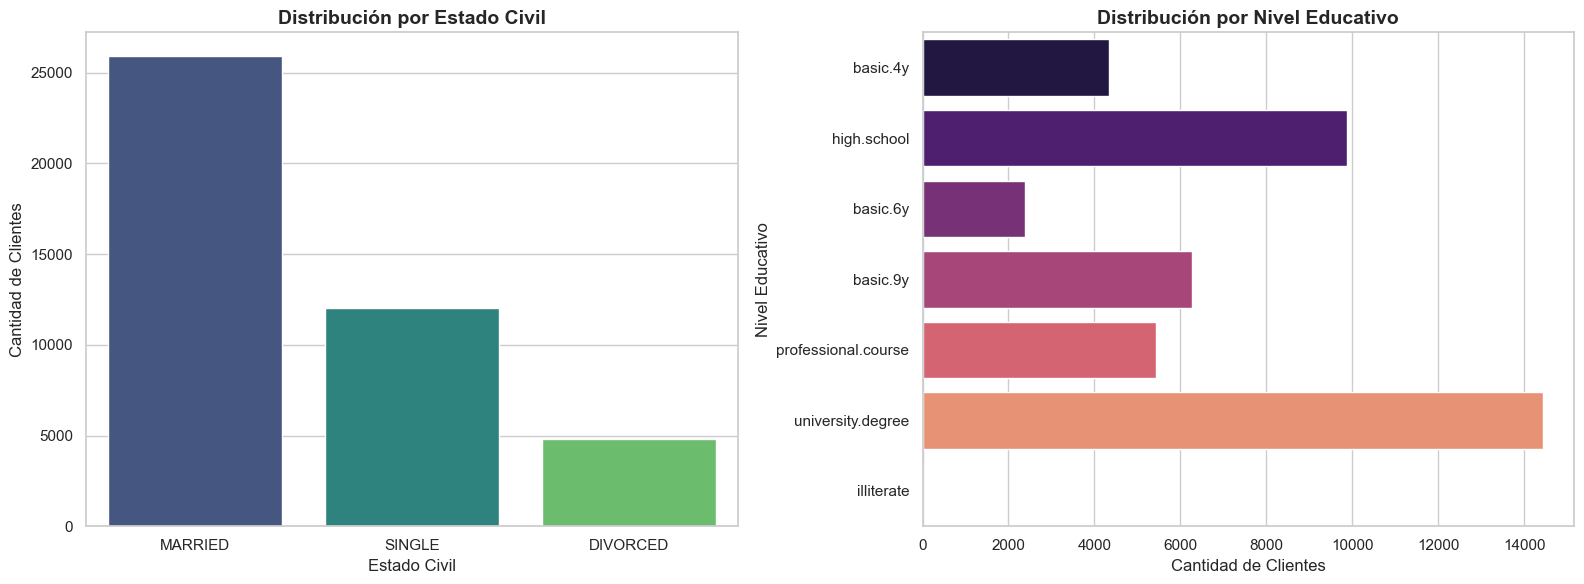

In [64]:
# Configuramos un lienzo ancho para poner DOS gráficos (1 fila, 2 columnas)
fig, ax = plt.subplots(1, 2, figsize=(16, 6)) # Creamos un lienzo con 1 fila y 2 columnas para colocar dos gráficos lado a lado, con un tamaño total de 16x6 pulgadas
sns.set_theme(style="whitegrid") # Aplica un estilo de fondo con cuadrícula para mejorar la legibilidad del gráfico

# Gráfico 1: Estado Civil (Barras Verticales) 
sns.countplot(data=df_clean, x='marital', hue='marital', palette='viridis', legend=False, ax=ax[0])
 # Gráfico de barras para la columna 'marital', con colores personalizados y sin leyenda (legend=False) porque el color ya indica la categoría
ax[0].set_title('Distribución por Estado Civil', fontsize=14, fontweight='bold') # Título del gráfico con tamaño de letra 14 y negrita
ax[0].set_xlabel('Estado Civil', fontsize=12) # Etiqueta del eje X con tamaño de letra 12
ax[0].set_ylabel('Cantidad de Clientes', fontsize=12) # Etiqueta del eje Y con tamaño de letra 12 

# Gráfico 2: Nivel Educativo (Barras Horizontales) 
sns.countplot(data=df_clean, y='education', hue='education', palette='magma', legend=False, ax=ax[1]) 
# Gráfico de barras horizontales para la columna 'education', con colores personalizados y sin leyenda (legend=False) porque el color ya indica la categoría, igual que el gráfico anterior
ax[1].set_title('Distribución por Nivel Educativo', fontsize=14, fontweight='bold') # Título del gráfico con tamaño de letra 14 y negrita
ax[1].set_xlabel('Cantidad de Clientes', fontsize=12) # Etiqueta del eje X con tamaño de letra 12
ax[1].set_ylabel('Nivel Educativo', fontsize=12) # Etiqueta del eje Y con tamaño de letra 12

# Ajustamos el espacio
plt.tight_layout() # Ajusta automáticamente el espacio entre los gráficos para que no se solapen ni queden demasiado separados
plt.show()

---

### 📝 Interpretación 

De las visualizaciones categóricas podemos extraer el perfil predominante de nuestra cartera de clientes:

Estado Civil: La gran mayoría de los clientes están casados (`MARRIED`), superando los 25,000 registros, lo que representa más del doble de los clientes solteros.
Nivel Educativo: El perfil educativo es alto. La categoría principal es el título universitario (`university.degree`), seguida muy de cerca por la educación secundaria (`high.school`). Los niveles de analfabetismo (`illiterate`) son prácticamente inexistentes en esta muestra.

Conclusión de Negocio: Las campañas de marketing del banco se dirigen principalmente a un público familiar (casados) con formación académica media-alta.

---

### 🔎 Matriz de Correlaciones : Identificando Motores Económicos.
Calcularemos la matriz de correlación de Pearson para identificar dependencias entre las variables numéricas. Esto nos permitirá priorizar los cruces de variables más significativos para el análisis bivariado.

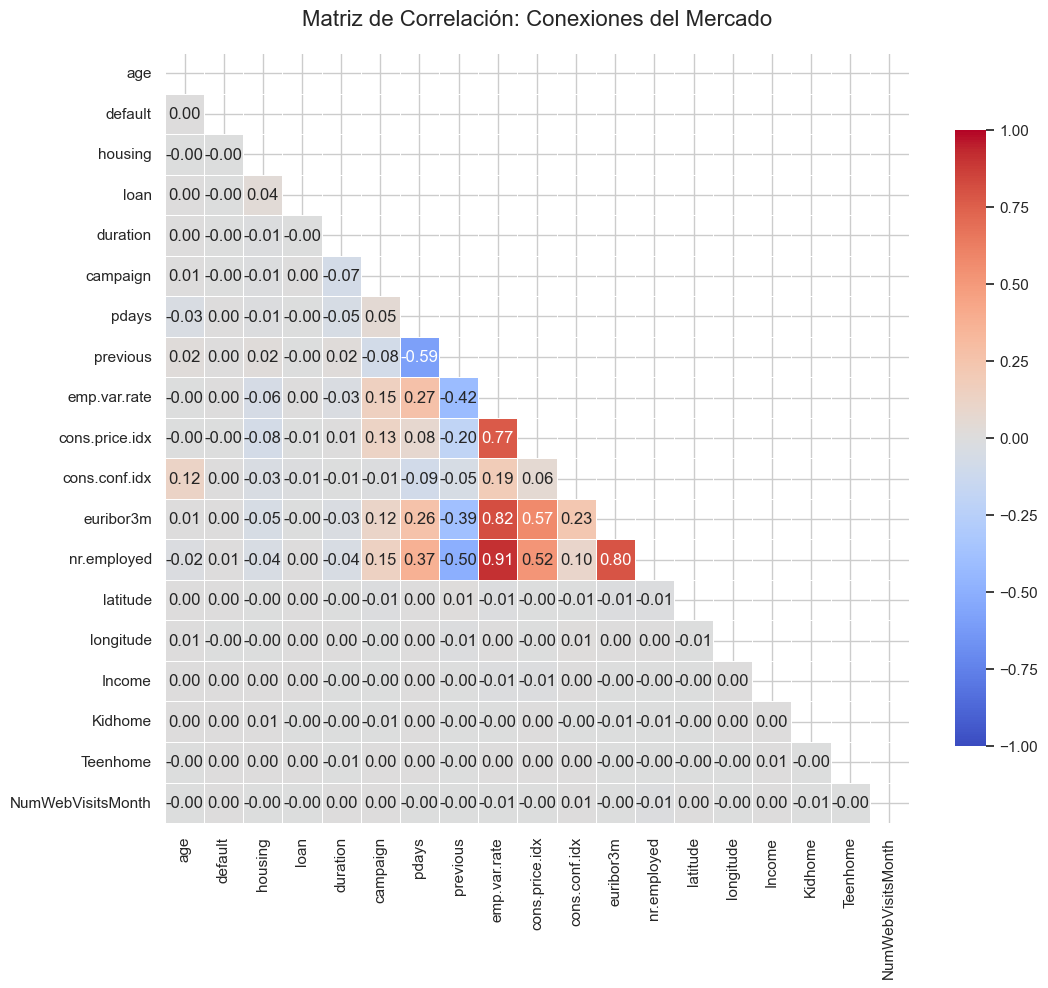

In [65]:
# 1. Calculamos la matriz de correlación (solo para números)
corr = df_clean.corr(numeric_only=True)

df_clean['y_binaria'] = df_clean['y'].map({'yes': 1, 'no': 0}) 
# Creamos una nueva columna 'y_binaria' donde 'yes' se convierte en 1 y 'no' en 0, para que pueda ser incluida en la matriz de correlación

mask = np.triu(np.ones_like(corr, dtype=bool)) # Creamos una máscara para ocultar la mitad superior de la matriz de correlación, ya que es simétrica y no aporta información adicional 
plt.figure(figsize=(12, 10)) # Configuramos el tamaño del gráfico para que sea lo suficientemente grande y legible, especialmente porque ahora tenemos más variables numéricas al incluir 'y_binaria'

# 2. Dibujamos el Heatmap
sns.heatmap(corr, 
            mask=mask,          # Aplicamos la máscara
            annot=True,         # Mostramos los números
            fmt=".2f",          # 2 decimales
            cmap='coolwarm',    # Color profesional (rojo/azul)
            vmin=-1, vmax=1,    # Forzamos la escala de -1 a 1
            center=0,           # El blanco siempre será el cero
            linewidths=.5,      # Líneas finas entre cuadros
            cbar_kws={"shrink": .8}) # Barra de color más elegante

plt.title('Matriz de Correlación: Conexiones del Mercado', fontsize=16, pad=20)
plt.show()



* **Independencia Demográfica:** Las variables personales del cliente (como edad, ingresos e hijos) muestran una correlación casi nula entre sí (valores cercanos a 0.00). No presentan dependencia lineal.
* **Fuerte Vínculo Macroeconómico:** Existe un bloque de alta correlación positiva (rojas intensas, valores > 0.75) entre los indicadores sociales y económicos: `emp.var.rate`, `euribor3m`, `nr.employed` y `cons.price.idx`. Esto confirma que estas variables macroeconómicas fluctúan en bloque.
* **Correlación Operativa:** Se observa una relación inversa lógica (-0.59) entre `pdays` y `previous`, relacionada con la gestión de contactos en campañas anteriores.
* **El Motor del Éxito (`y_binaria`):** Al analizar la variable objetivo, descubrimos que el factor que más influye positivamente en el éxito de la campaña es la duración del contacto (`duration`, con 0.41). A mayor tiempo de conversación, mayor probabilidad de conversión. Por el contrario, los contextos macroeconómicos desfavorables (correlaciones negativas) dificultan el éxito de la campaña.

----

### 📊 Análisis Bivariado: Relaciones Descubiertas

Guiados por la Matriz de Correlación, profundizaremos en el cruce de variables clave. Comenzando por validar el fuerte vínculo positivo encontrado entre los indicadores macroeconómicos.

Gráfico de Dispersión (Scatterplot) del Euribor vs la Tasa de Empleo.

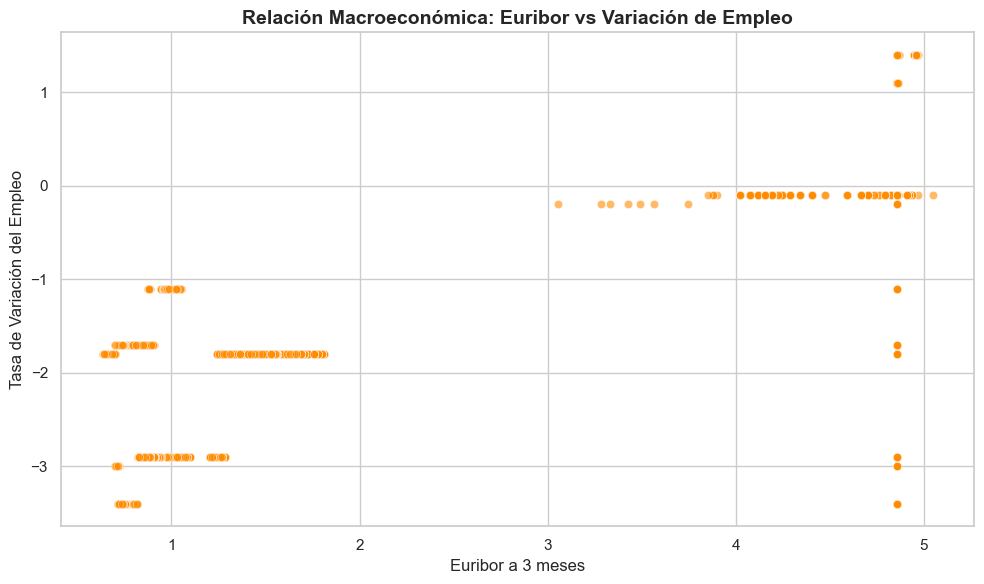

In [66]:
# Configuramos el lienzo
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Gráfico de Dispersión (Scatterplot)
sns.scatterplot(data=df_clean, x='euribor3m', y='emp.var.rate', color='darkorange', alpha=0.6)

# Títulos y etiquetas
plt.title('Relación Macroeconómica: Euribor vs Variación de Empleo', fontsize=14, fontweight='bold')
plt.xlabel('Euribor a 3 meses', fontsize=12)
plt.ylabel('Tasa de Variación del Empleo', fontsize=12)

plt.tight_layout()
plt.show()

---
### 📝 Interpretación 

El gráfico confirma visualmente la fuerte correlación positiva (0.82) detectada en la matriz. Observamos la formación de "clusters" (grupos) muy marcados, lo cual es propio de los indicadores macroeconómicos que se mantienen estables durante periodos de tiempo antes de cambiar bruscamente. En general, escenarios de Euribor alto coinciden con tasas de variación de empleo positivas en esta muestra.

----

### 🚀 Éxito de la Campaña por Ocupación (job)

Usaremos un gráfico de barras


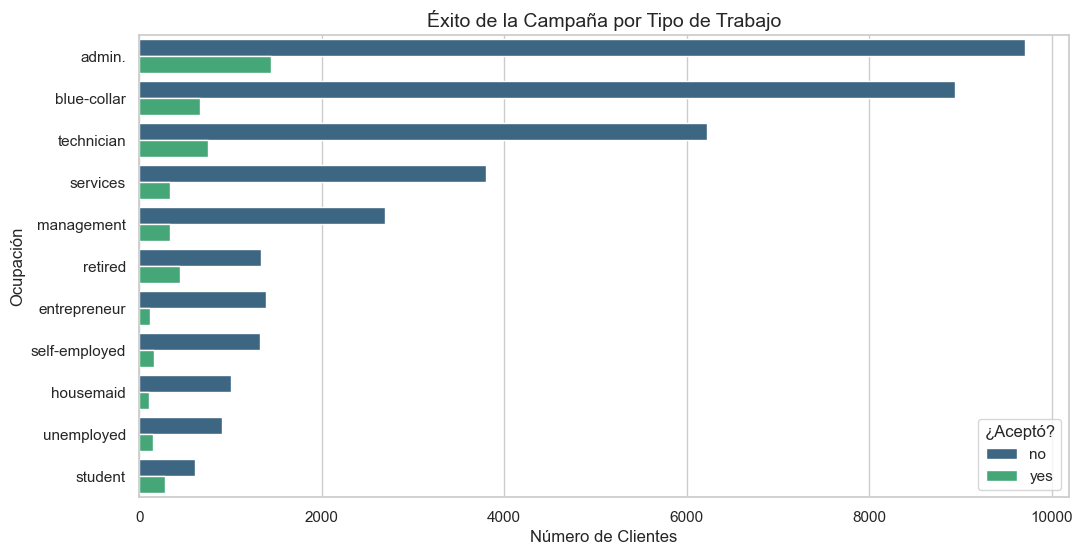

In [67]:
plt.figure(figsize=(12, 6))
# Usamos un gráfico de barras comparativo
sns.countplot(data=df_clean, y='job', hue='y', palette='viridis',  # Gráfico de barras horizontales para la columna 'job', con el color indicando si aceptaron o no la campaña (hue='y') y una paleta de colores profesional
              order=df_clean['job'].value_counts().index) # Ordenamos las barras según la frecuencia de cada tipo de trabajo para mejorar la legibilidad y destacar los trabajos más comunes

plt.title('Éxito de la Campaña por Tipo de Trabajo', fontsize=14)
plt.xlabel('Número de Clientes') # Etiqueta del eje X con texto "Número de Clientes"
plt.ylabel('Ocupación') # Etiqueta del eje Y con texto "Ocupación"
plt.legend(title='¿Aceptó?', loc='lower right') # Leyenda para indicar qué color corresponde a "yes" y cuál a "no", con el título "¿Aceptó?" y ubicada en la esquina inferior derecha del gráfico
plt.show()


---
### 📝 Interpretación de segmentación por trabajo: 

Se observa que el volumen de llamadas está concentrado en perfiles administrativos y técnicos. Sin embargo, la tasa de conversión es baja en todos los segmentos. Esto sugiere que el éxito no depende tanto del perfil del cliente, sino de la interacción durante la llamada.

---

### 📊 Análisis Multivariado: Relación entre el Perfil Laboral, la Duración de la Llamada y el Éxito de Conversión

¿Necesitan todos los perfiles el mismo tiempo de llamada para ser convencidos?

A continuación, observamos cómo el tiempo promedio de llamada se dispara en todos los segmentos cuando el resultado es positivo.

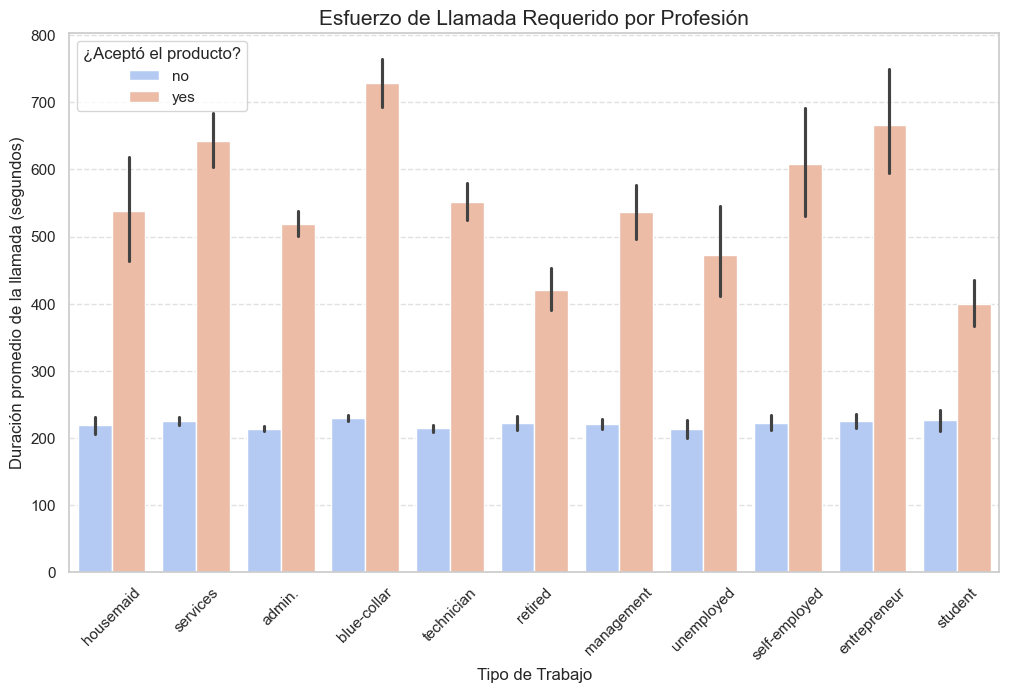

In [68]:
plt.figure(figsize=(12, 7))

# Usamos barplot para ver promedios (la rayita negra arriba es el intervalo de confianza)
sns.barplot(data=df_clean, x='job', y='duration', hue='y', palette='coolwarm')

plt.title('Esfuerzo de Llamada Requerido por Profesión', fontsize=15)
plt.ylabel('Duración promedio de la llamada (segundos)')
plt.xlabel('Tipo de Trabajo')
plt.xticks(rotation=45)
plt.legend(title='¿Aceptó el producto?')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()




---

### 📝 Interpretación 

Este gráfico revela tres hallazgos estratégicos fundamentales:

La "Barrera del Tiempo" es Universal: Sin importar la profesión del cliente, existe una diferencia abismal entre la duración de las llamadas fallidas  y las exitosas. Esto confirma que el éxito no es azaroso, sino que requiere una inversión de tiempo mínima.

Segmentos de "Alta Resistencia": Los perfiles de Blue-collar, Entrepreneur y Services son los que más tiempo exigen al teléfono para dar un "sí". Son clientes difíciles de convencer, pero que escuchan si el argumento es sólido.

Segmentos de "Decisión Rápida": Los Students y Retired (estudiantes y jubilados) tienen los tiempos de conversión más bajos entre los éxitos. Esto indica que son segmentos más receptivos o con procesos de decisión más sencillos, lo que los convierte en objetivos de "alta eficiencia" para el banco.

---

### ⏱️ El Factor Tiempo: Duración vs. Éxito de la Campaña

Tras identificar en la matriz de correlación que la duración de la llamada (`duration`) es la variable que más influye positivamente en la conversión (`y`), procedemos a validar esta relación visualmente. 

A través del siguiente diagrama de caja (Boxplot), comparamos la distribución de los tiempos de conversación entre los clientes que rechazaron la oferta (no) y aquellos que finalmente la aceptaron (yes).

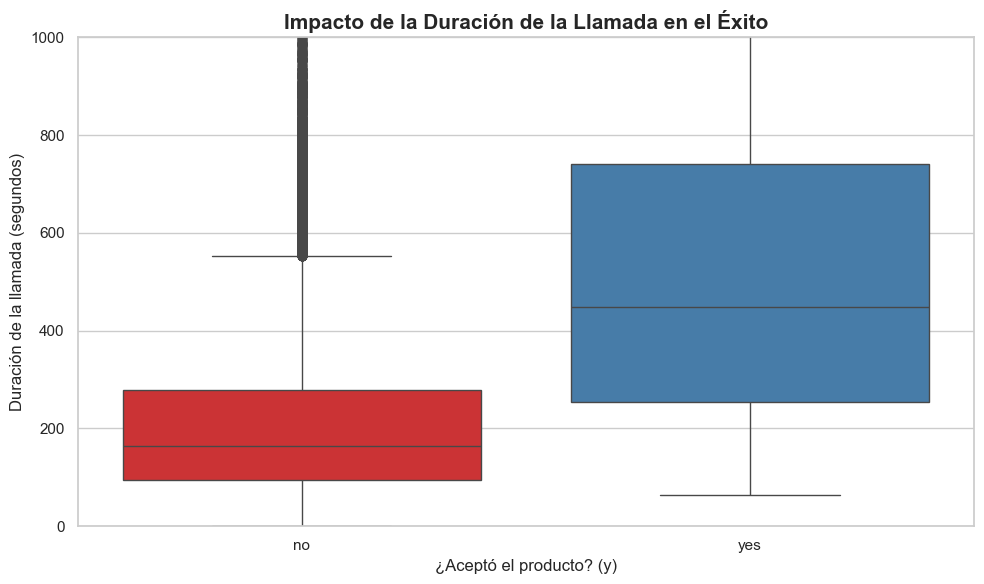

In [69]:
# 1. Configuramos el lienzo
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# 2. Creamos el Boxplot
# Cruzamos el éxito (eje X) con la duración (eje Y)
sns.boxplot(data=df_clean, x='y', y='duration', hue='y', palette='Set1', legend=False) 
# Boxplot cruzando 'y' (éxito) con 'duration' (duración de la llamada), con colores personalizados y sin leyenda porque el color ya indica la categoría

# 3. Personalización profesional
plt.title('Impacto de la Duración de la Llamada en el Éxito', fontsize=15, fontweight='bold')
plt.xlabel('¿Aceptó el producto? (y)', fontsize=12)
plt.ylabel('Duración de la llamada (segundos)', fontsize=12)

# 4. Ajuste de escala (limite para ignorar outliers extremos que deforman la caja)
plt.ylim(0, 1000) # Limite el eje Y para que los outliers extremos no deformen la visualización de la caja, enfocándonos en la mayoría de los datos que están por debajo de 1000 segundos 

plt.tight_layout()
plt.show()

---

### Interpretación:

El diagrama de caja confirma de manera contundente la hipótesis planteada en la matriz de correlación: **el tiempo es el factor decisivo**. 

Observamos una diferencia drástica en las medianas de ambos grupos. Los clientes que rechazan la campaña (caja roja) tienden a finalizar la llamada rápidamente (mediana inferior a 200 segundos). Por el contrario, los casos de éxito (caja azul) requieren llamadas significativamente más largas (mediana en torno a 450 segundos). 

**Recomendación Operativa:** El banco debería enfocar el entrenamiento de sus comerciales en técnicas de retención telefónica en los primeros 3 minutos de la llamada, ya que superar esa barrera temporal aumenta drásticamente la probabilidad de conversión.

---

### 🏁 ***Resumen Metodológico del Análisis***

Para llegar a los hallazgos presentados a continuación, se procesó un dataset de 43,000 registros. El análisis comenzó con una fase de curación de datos donde se unificaron fuentes de Excel y CSV, se imputaron valores nulos mediante técnicas estadísticas (mediana) y se corrigieron formatos económicos para permitir un análisis cuantitativo riguroso.
A través de un enfoque de EDA progresivo (Univariado → Bivariado → Multivariado), se validaron hipótesis sobre el comportamiento del cliente y se identificó la duración de la llamada como el factor operativo de mayor impacto en la conversión.

### 💡 ***Conclusiones***


🌍 Contexto Económico Inevitable: El análisis bivariado entre el Euribor y la tasa de empleo confirma que el entorno macroeconómico es un factor externo que influye en el dataset. El banco debe ser consciente de que las campañas serán más o menos difíciles según el ciclo económico actual.
* *Recomendación:* El banco debe modular la intensidad de las llamadas y ajustar sus expectativas de conversión basándose en la salud del entorno económico trimestral.

🎯 Segmentación de Nicho vs. Volumen: Aunque la mayoría de las llamadas se dirigen a perfiles administrativos y obreros, observamos que sectores como estudiantes y jubilados muestran una receptividad proporcionalmente mayor, ya que aceptan la oferta en casi la mitad de tiempo de la que se demoran con los perfiles anteriores. 
* *Recomendación:* Ajustar la estrategia para priorizar estos nichos con alta tasa de conversión.

⏱️ El Factor de Éxito Crítico (Engagement): Tras el análisis multivariado y de duración, se concluye que el tiempo es el recurso más valioso. Una llamada exitosa requiere, de media, el triple de tiempo que una fallida.
* *Recomendación:* No se trata solo de a quién llamamos, sino de cuánto logramos retenerlos. Se sugiere entrenar a los operadores para superar la "barrera de los 5 minutos", ya que es ahí donde ocurren la mayoría de las ventas.

---